In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
dataset_path = (
    "/content/drive/MyDrive/"
    "TOGG_Driver_Risk_Project/"
    "data/processed/"
    "uah_full_dataset.csv"
)

df = pd.read_csv(dataset_path)

df.head()

,acc_resultant_mean,acc_resultant_std,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_horizontal_mean,acc_horizontal_std,acc_horizontal_min,acc_horizontal_max,...,pitch_rms,yaw_mean,yaw_std,yaw_min,yaw_max,yaw_median,yaw_rms,driver,road_type,behavior
0,0.041557,0.015206,0.019339,0.075226,0.037947,0.044164,0.036259,0.015678,0.012207,0.075166,...,0.021821,0.019100,0.005182,0.011,0.025,0.0215,0.019768,D1,SECONDARY,NORMAL
1,0.041732,0.015063,0.019339,0.075226,0.037947,0.044282,0.036556,0.015447,0.012207,0.075166,...,0.022052,0.019533,0.005111,0.011,0.025,0.0220,0.020169,D1,SECONDARY,NORMAL
2,0.041103,0.015089,0.019339,0.075226,0.036665,0.043698,0.035783,0.015511,0.012207,0.075166,...,0.022413,0.020033,0.005082,0.011,0.027,0.0220,0.020647,D1,SECONDARY,NORMAL
3,0.039805,0.015016,0.019339,0.075226,0.034974,0.042455,0.034164,0.016026,0.005831,0.075166,...,0.022767,0.020667,0.005101,0.011,0.030,0.0220,0.021267,D1,SECONDARY,NORMAL
4,0.040324,0.015078,0.019339,0.075226,0.036665,0.042963,0.035077,0.016086,0.005831,0.075166,...,0.023116,0.021333,0.005101,0.011,0.031,0.0225,0.021915,D1,SECONDARY,NORMAL


In [4]:
print(df.shape)

df.info()

(310225, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310225 entries, 0 to 310224
Data columns (total 45 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   acc_resultant_mean     310225 non-null  float64
 1   acc_resultant_std      310225 non-null  float64
 2   acc_resultant_min      310225 non-null  float64
 3   acc_resultant_max      310225 non-null  float64
 4   acc_resultant_median   310225 non-null  float64
 5   acc_resultant_rms      310225 non-null  float64
 6   acc_horizontal_mean    310225 non-null  float64
 7   acc_horizontal_std     310225 non-null  float64
 8   acc_horizontal_min     310225 non-null  float64
 9   acc_horizontal_max     310225 non-null  float64
 10  acc_horizontal_median  310225 non-null  float64
 11  acc_horizontal_rms     310225 non-null  float64
 12  speed_mean             310225 non-null  float64
 13  speed_std              310225 non-null  float64
 14  speed_min              

In [5]:
df.isnull().sum()

,0
acc_resultant_mean,0
acc_resultant_std,0
acc_resultant_min,0
acc_resultant_max,0
acc_resultant_median,0
acc_resultant_rms,0
acc_horizontal_mean,0
acc_horizontal_std,0
acc_horizontal_min,0
acc_horizontal_max,0


In [6]:
df["behavior"].value_counts()

,count
behavior,
NORMAL,131373
DROWSY,99504
AGGRESSIVE,79348


In [7]:
target_column = "behavior"

feature_columns = [
    col for col in df.columns
    if col not in [
        "behavior",
        "driver",
        "road_type"
    ]
]

X = df[feature_columns]

y = df[target_column]

print(X.shape)
print(y.shape)

(310225, 42)
(310225,)


In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [9]:
mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

mapping

{'AGGRESSIVE': np.int64(0), 'DROWSY': np.int64(1), 'NORMAL': np.int64(2)}

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(248180, 42)
(62045, 42)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(248180, 42)


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [13]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([0, 0, 1, 0, 2, 1, 1, 1, 2, 2])

In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9999


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       1.00      1.00      1.00     15870
      DROWSY       1.00      1.00      1.00     19901
      NORMAL       1.00      1.00      1.00     26274

    accuracy                           1.00     62045
   macro avg       1.00      1.00      1.00     62045
weighted avg       1.00      1.00      1.00     62045



<Figure size 700x700 with 0 Axes>

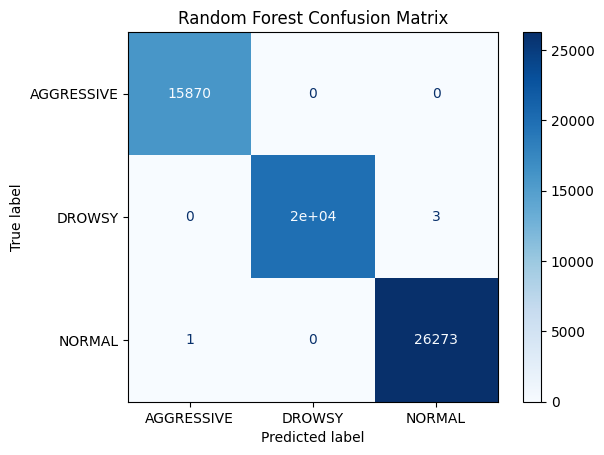

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7,7))

disp.plot(
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [17]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
39,yaw_max,0.058377
41,yaw_rms,0.058054
40,yaw_median,0.057419
38,yaw_min,0.056429
15,speed_max,0.053653
36,yaw_mean,0.052463
16,speed_median,0.045013
12,speed_mean,0.043684
17,speed_rms,0.042468
14,speed_min,0.039455


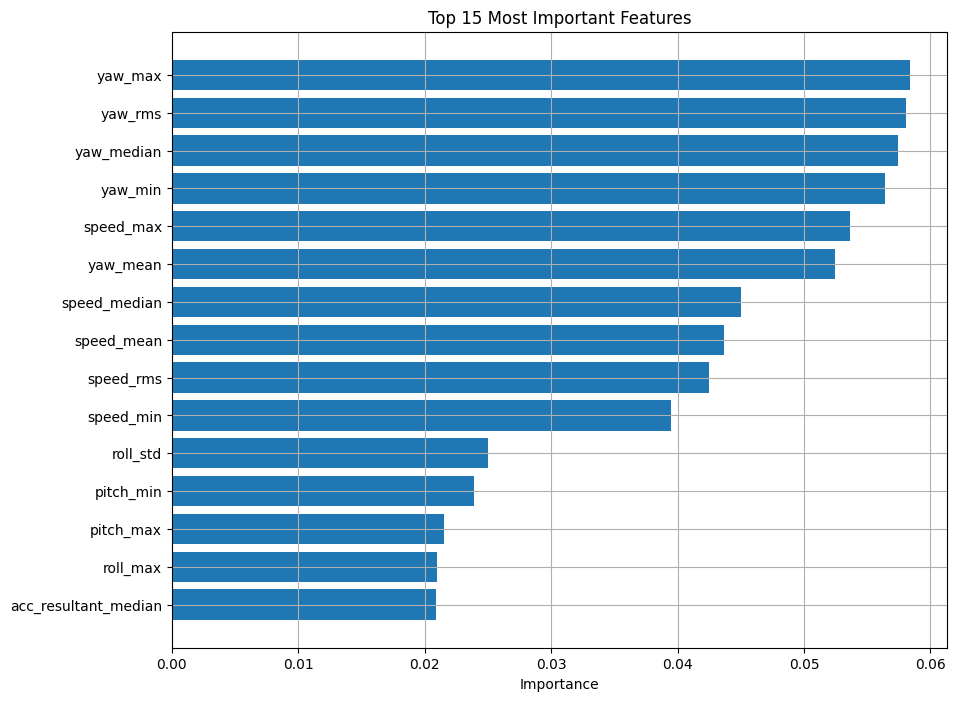

In [18]:
plt.figure(figsize=(10,8))

plt.barh(

    feature_importance["Feature"][:15][::-1],

    feature_importance["Importance"][:15][::-1]

)

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.grid(True)

plt.show()